In [107]:
import mdtraj as md
import nglview as nv
import numpy as np

import matplotlib.pyplot as plt

# Water

In [131]:
h5_path = "/Users/fleurdolmans/Documents/UvA/Master AI/Thesis/HDD/data/molecules/md/water/waterInwater_dim54_temp300_eq10000_burn100000_steps10000000_fpt0.5_every10_ecTrue_r0.3_fc10000.0_icnone_rwFalse.h5"
traj = md.load_hdf5(h5_path)

#### Basic Droplet Info

In [134]:
# Basic droplet info
print("Number of Frames:", traj.n_frames)
print("Total number of Atoms:", traj.n_atoms)
print("Number of residues:", traj.n_residues)

view = nv.show_mdtraj(traj)
view.clear_representations()

# solvent first: transparent
view.add_representation(
    "licorice",
    selection="all"
)

# solute water second: thick + red
view.add_representation(
    "ball+stick",
    selection="@0,1,2",
    colorValue="red",
    radius=0.2
)

view.center()
view



Number of Frames: 1000000
Total number of Atoms: 18
Number of residues: 6


NGLWidget(max_frame=999999)

In [135]:
# Number of solvent and solute atoms in droplet
top = traj.topology

table, bonds = top.to_dataframe()
print(table.head())


  serial name element  resSeq resName  chainID segmentID  formal_charge
0   None    O       O       1     HOH        0                     <NA>
1   None   H1       H       1     HOH        0                     <NA>
2   None   H2       H       1     HOH        0                     <NA>
3   None    O       O       2     HOH        1                     <NA>
4   None   H1       H       2     HOH        1                     <NA>


In [136]:
solute = top.select("resid 0")                 # first water = solute
solvent = top.select("water and not resid 0")  # rest = solvent

solvent_O = top.select("water and element O and not resid 0")
solvent_H = top.select("water and element H and not resid 0")

print("Number of atoms in solute:", solute.size)
print("Number of atoms in solvent:", solvent.size)
print("Number of oxygen atoms in solvent:", solvent_O.size)
print("Number of hydrogen atoms in solvent:", solvent_H.size)


Number of atoms in solute: 3
Number of atoms in solvent: 15
Number of oxygen atoms in solvent: 5
Number of hydrogen atoms in solvent: 10


## Radial distribution function


$g(r) = \frac{\langle \rho (r)\rangle }{\rho}=\frac{\text{local number of density at distance } r}{\text{bulk number desity}} $

### Solvation structure (S-O(water))
How close do the center of water molecules (solvent) approach the solute center?


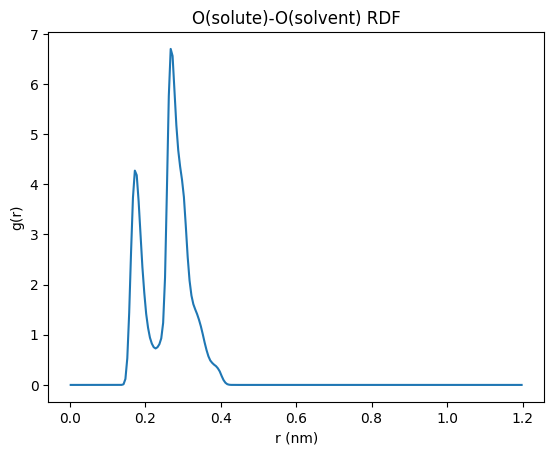

In [137]:
pairs = traj.topology.select_pairs(solute, solvent_O)

r, g_r = md.compute_rdf(
    traj,
    pairs=pairs,
    r_range=(0.0, 1.2),  # nm
    bin_width=0.005
)

plt.plot(r, g_r)
plt.xlabel("r (nm)")
plt.ylabel("g(r)")
plt.title("O(solute)-O(solvent) RDF")
plt.show()


In [138]:
rho = len(solvent_O) / traj.unitcell_volumes.mean()  # number density
print("The average number of solvent (water) molecules per unit volume (number density) is:", rho, "nm^-3")

coord_number = 4 * np.pi * rho * np.trapz(g_r * r**2, r)
print("Coordination number:", coord_number)

The average number of solvent (water) molecules per unit volume (number density) is: 9.98114452394593 nm^-3
Coordination number: 4.999852837757337


/var/folders/tx/zbry1_2j2_57jk0nsqv4m9080000gn/T/ipykernel_61383/3199095728.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coord_number = 4 * np.pi * rho * np.trapz(g_r * r**2, r)


## Solvent Leakage

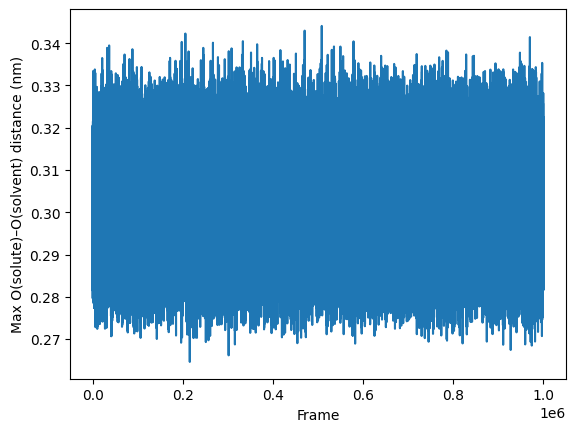

In [118]:
solute_O = top.select("resid 0 and element O")                 # 1 oxygen atom

pairs = top.select_pairs(solute_O, solvent_O)   # (n_solvent_waters, 2)
d = md.compute_distances(traj, pairs)           # shape (n_frames, n_solvent_waters)

max_dist_per_frame = d.max(axis=1)

plt.plot(max_dist_per_frame)
plt.xlabel("Frame")
plt.ylabel("Max O(solute)–O(solvent) distance (nm)")
plt.show()


# SO2

In [124]:
h5_path = "/Users/fleurdolmans/Documents/UvA/Master AI/Thesis/HDD/data/molecules/md/so2/so2Inwater_dim54_temp300_eq10000_burn100000_steps10000000_fpt0.5_every10_ecTrue_r0.3_fc10000.0_icnone_rwFalse.h5"
traj = md.load_hdf5(h5_path)

#### Basic Droplet Info

In [125]:
# Basic droplet info
print("Number of Frames:", traj.n_frames)
print("Total number of Atoms:", traj.n_atoms)
print("Number of residues:", traj.n_residues)

view = nv.show_mdtraj(traj)
view.clear_representations()
# view.add_representation("ball+stick", selection="all")   # show all atoms
view.center()


# solvent
view.add_representation(
    "licorice",
    selection="all"
)

# solute 
view.add_representation(
    "ball+stick",
    selection="@0,1,2",
    radius=0.2
)

view

Number of Frames: 1000000
Total number of Atoms: 18
Number of residues: 6


NGLWidget(max_frame=999999)

In [126]:
# Number of solvent and solute atoms in droplet
top = traj.topology

table, bonds = top.to_dataframe()
print(table.head())


  serial name element  resSeq resName  chainID segmentID  formal_charge
0   None    S       S       1     SO2        0                     <NA>
1   None   O1       O       1     SO2        0                     <NA>
2   None   O2       O       1     SO2        0                     <NA>
3   None    O       O       2     HOH        1                     <NA>
4   None   H1       H       2     HOH        1                     <NA>


In [127]:
solute = top.select("not water")
solvent = top.select("water")
solvent_O = top.select("water and element O")
solvent_H = top.select("water and element H")

print("Number of atoms in solute:", solute.size)
print("Number of atoms in solvent:", solvent.size)
print("Number of oxygen atoms in solvent:", solvent_O.size)
print("Number of hydrogen atoms in solvent:", solvent_H.size)

Number of atoms in solute: 3
Number of atoms in solvent: 15
Number of oxygen atoms in solvent: 5
Number of hydrogen atoms in solvent: 10


## Radial distribution function


$g(r) = \frac{\langle \rho (r)\rangle }{\rho}=\frac{\text{local number of density at distance } r}{\text{bulk number desity}} $

### Solvation structure (S-O(water))
How close do the center of water molecules (solvent) approach the solute center?


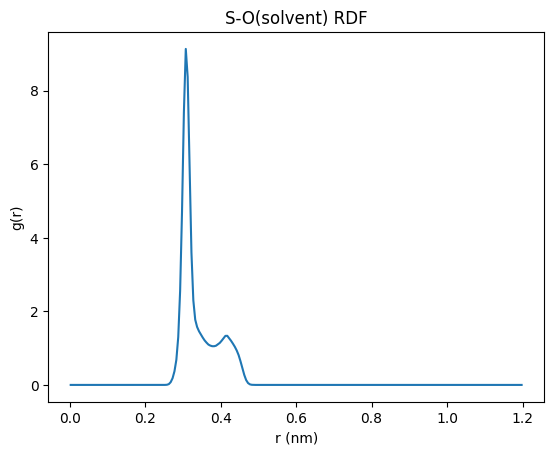

In [128]:
pairs = traj.topology.select_pairs(solute, solvent_O)

r, g_r = md.compute_rdf(
    traj,
    pairs=pairs,
    r_range=(0.0, 1.2),  # nm
    bin_width=0.005
)

plt.plot(r, g_r)
plt.xlabel("r (nm)")
plt.ylabel("g(r)")
plt.title("S-O(solvent) RDF")
plt.show()


In [129]:
rho = len(solvent_O) / traj.unitcell_volumes.mean()  # number density
print("The average number of solvent (water) molecules per unit volume (number density) is:", rho, "nm^-3")

coord_number = 4 * np.pi * rho * np.trapz(g_r * r**2, r)
print("Coordination number:", coord_number)

The average number of solvent (water) molecules per unit volume (number density) is: 8.738196139118083 nm^-3
Coordination number: 4.999911779033744


/var/folders/tx/zbry1_2j2_57jk0nsqv4m9080000gn/T/ipykernel_61383/3199095728.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coord_number = 4 * np.pi * rho * np.trapz(g_r * r**2, r)


## Solvent Leakage

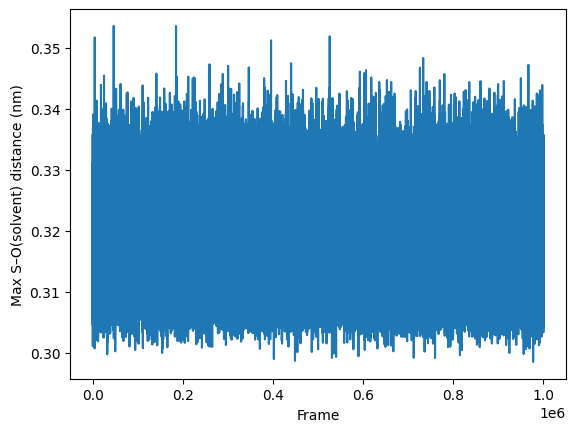

In [130]:
solute_S = top.select("not water and element S")

pairs = top.select_pairs(solute_S, solvent_O)
d = md.compute_distances(traj, pairs)  # shape (frames, waters)

max_dist_per_frame = d.max(axis=1)

plt.plot(max_dist_per_frame)
plt.xlabel("Frame")
plt.ylabel("Max S–O(solvent) distance (nm)")
plt.show()

Solute is engulfed by solvent over all frames, the droplet does not leak, and water exchange does not occur.
